# Analyzing MNIST dataset

The main goal of this notebook is to show how we can implement different ML algorithms from MNIST dataset. MNIST dataset is a very simple ML educational dataset, with handwrtten digits and their labels. The main task that is asked usually in exercises is the classification of the digits.

However, in this notebook we will try to go one step further and release the full potential of this dataset by implementing models addressing different tasks.

I hope that this notebook would be useful for your learning! Personally, I was quite excited while I was working on that and it helped me organize my knowledge regarding image classification and generation with neural networks.

## Importing the data

In [1]:
import numpy as np
import struct

# -------------------------
# Function to load MNIST ubyte
# -------------------------
def load_mnist_images(filename, max_samples=None):
    with open(filename, 'rb') as f:
        # Read header
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        # Read data
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
        # Normalize to [0,1]
        images = images.astype(np.float32) / 255.0
        if max_samples:
            images = images[:max_samples]
        return images

def load_mnist_labels(filename, max_samples=None):
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        if max_samples:
            labels = labels[:max_samples]
        return labels

In [2]:
# -------------------------
# Load small subset
# -------------------------
train_images = load_mnist_images('../input/mnist-dataset/train-images.idx3-ubyte', max_samples=5000)
train_labels = load_mnist_labels('../input/mnist-dataset/train-labels.idx1-ubyte', max_samples=5000)

test_images = load_mnist_images('../input/mnist-dataset/t10k-images.idx3-ubyte', max_samples=1000)
test_labels = load_mnist_labels('../input/mnist-dataset/t10k-labels.idx1-ubyte', max_samples=1000)

print("Train images:", train_images.shape)
print("Train labels:", train_labels.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Train images: (5000, 28, 28)
Train labels: (5000,)
Test images: (1000, 28, 28)
Test labels: (1000,)


Usually, in any classification task after I import the data, I check what are the classes, and how many entries are for each of them. In general, I check if the classes are balanced or imbalanced.

Here we have a problem, where the classes are quite balanced, and this is good, because it is what makes MNIST dataset good as an easy exercise.

=== Train Dataset ===
Number of samples: 5000
Image shape: (28, 28)
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Class 0: 479 samples
Class 1: 563 samples
Class 2: 488 samples
Class 3: 493 samples
Class 4: 535 samples
Class 5: 434 samples
Class 6: 501 samples
Class 7: 550 samples
Class 8: 462 samples
Class 9: 495 samples


/tmp/ipykernel_25/1172102406.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=np.arange(len(class_counts)), y=class_counts, palette="viridis")


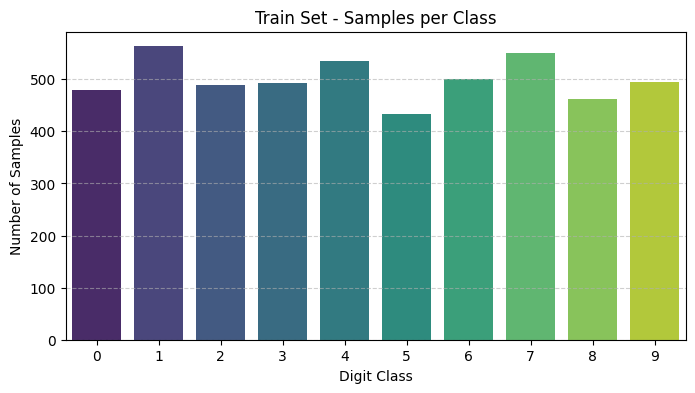

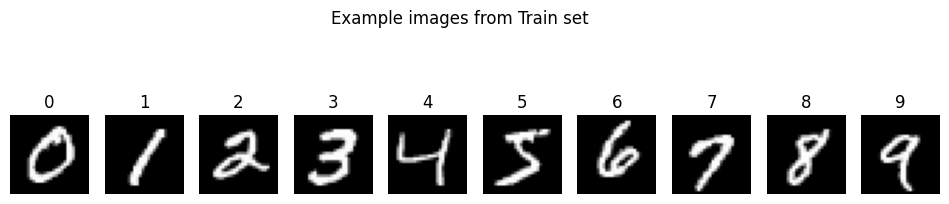

=== Test Dataset ===
Number of samples: 1000
Image shape: (28, 28)
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Class 0: 85 samples
Class 1: 126 samples
Class 2: 116 samples
Class 3: 107 samples
Class 4: 110 samples
Class 5: 87 samples
Class 6: 87 samples
Class 7: 99 samples
Class 8: 89 samples
Class 9: 94 samples


/tmp/ipykernel_25/1172102406.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=np.arange(len(class_counts)), y=class_counts, palette="viridis")


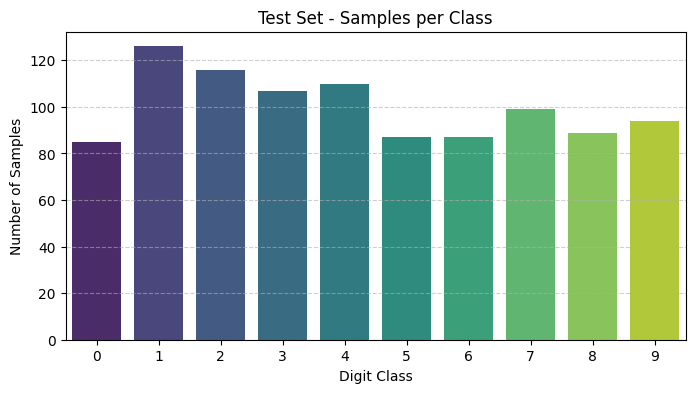

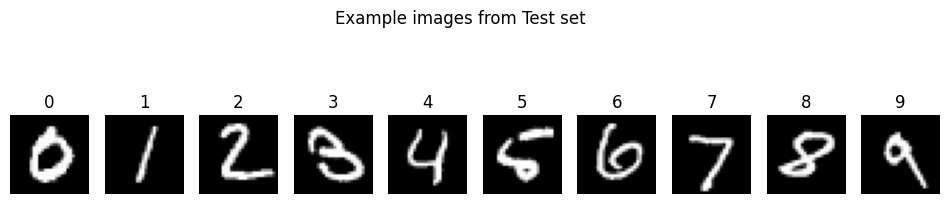

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

def dataset_statistics(images, labels, dataset_name="Train"):
    print(f"=== {dataset_name} Dataset ===")
    print("Number of samples:", len(labels))
    print("Image shape:", images.shape[1:])  # skip batch dimension
    print("Unique labels:", np.unique(labels))
    
    # Count samples per class
    class_counts = np.bincount(labels)
    for i, count in enumerate(class_counts):
        print(f"Class {i}: {count} samples")
    
    # Plot class distribution
    plt.figure(figsize=(8,4))
    sns.barplot(x=np.arange(len(class_counts)), y=class_counts, palette="viridis")
    plt.title(f"{dataset_name} Set - Samples per Class")
    plt.xlabel("Digit Class")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()
    
    # Optional: show some example images from each class
    plt.figure(figsize=(12,3))
    for i in range(10):
        idx = np.where(labels == i)[0][0]  # first sample of class i
        plt.subplot(1, 10, i+1)
        plt.imshow(images[idx], cmap='gray')
        plt.axis('off')
        plt.title(f"{i}")
    plt.suptitle(f"Example images from {dataset_name} set")
    plt.show()

# -------------------------
# Run diagnostics
# -------------------------
dataset_statistics(train_images, train_labels, "Train")
dataset_statistics(test_images, test_labels, "Test")

Moreover, if we plot the images, we will see that they are already pre-processed. They have the same dimensions, they are normalized in black-white format.

This is very important because it allows us to focus on the modelling part of the exercise, instead of fighting with the pre-processing.

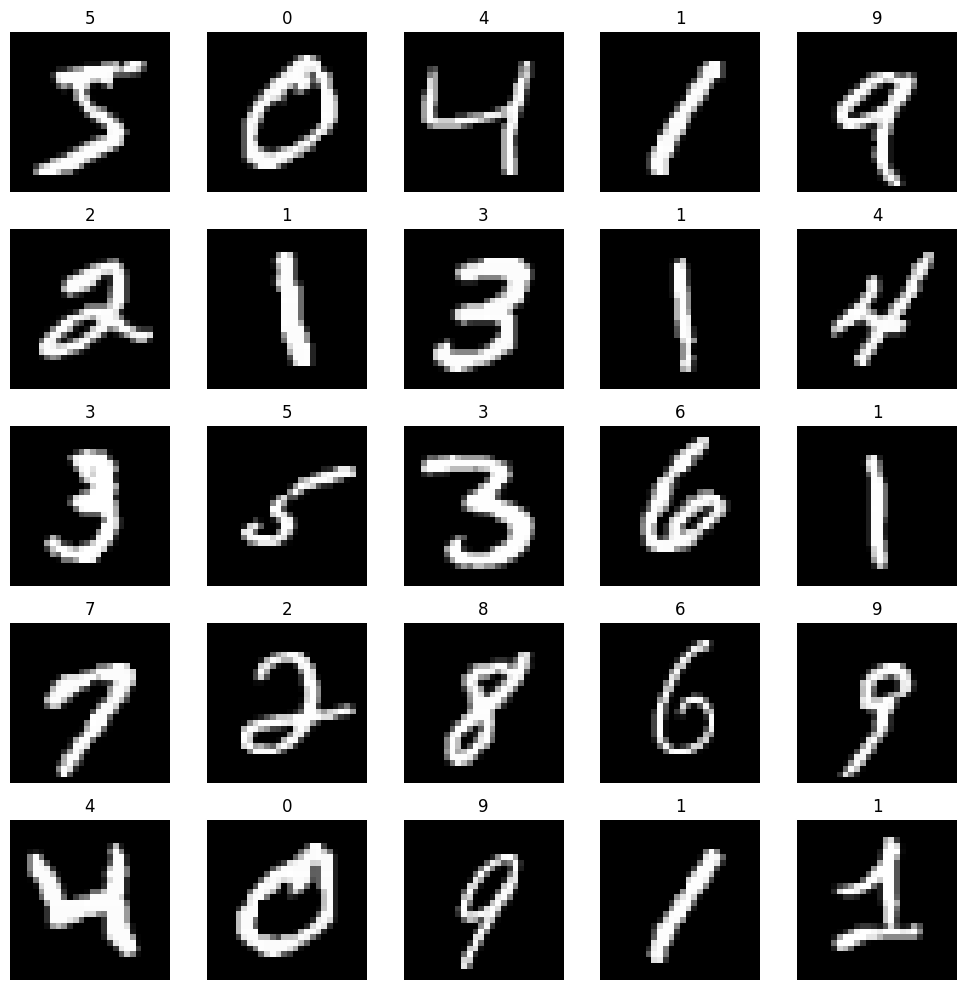

In [4]:
import matplotlib.pyplot as plt

# -------------------------
# Function to plot 5x5 grid
# -------------------------
def plot_mnist_grid(images, labels, grid_size=5):
    """
    Plots a grid of MNIST images with labels.

    images: numpy array of shape (N, 28, 28)
    labels: numpy array of shape (N,)
    grid_size: number of rows and cols (default 5x5)
    """
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    axes = axes.flatten()
    
    for i in range(grid_size * grid_size):
        axes[i].imshow(images[i], cmap='gray')
        axes[i].set_title(str(labels[i]))
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# -------------------------
# Example usage with your data
# -------------------------
plot_mnist_grid(train_images, train_labels)

# Mapping metrics_names to the actual scorer keys in cv_results

The goal of this task is to classify handwritten digits (0–9) from the MNIST dataset. Each input is a 28×28 grayscale image, flattened into a vector of 784 features, and the target is a digit label. The task is a multi-class classification problem with 10 classes.

## Classic ML


We apply a variety of **classical machine learning algorithms** to compare their performance on this dataset:

1. **Logistic Regression**

   * A linear model that predicts class probabilities using a softmax function.
   * Works surprisingly well on MNIST after flattening images, despite its simplicity.

2. **K-Nearest Neighbors (KNN)**

   * A non-parametric method that classifies a sample based on the majority label of its nearest neighbors in feature space.
   * Simple, interpretable, and often strong for small or medium datasets.

3. **Decision Tree**

   * A tree-based model that splits features recursively to maximize information gain.
   * Captures nonlinear patterns in the data but can overfit if too deep.

4. **Gaussian Naive Bayes (GaussianNB)**

   * Assumes features are **conditionally independent given the class** and follow a Gaussian distribution.
   * Very fast, though the independence assumption is strong.

5. **Linear Support Vector Classifier (LinearSVC)**

   * Finds a hyperplane that maximizes the margin between classes.
   * Works well for high-dimensional data like flattened images.

6. **Extra Trees Classifier**

   * An ensemble of randomized decision trees that reduces overfitting by averaging multiple trees.
   * Captures nonlinear patterns efficiently and is robust to noisy features.



**Evaluation Metrics**

To evaluate the performance of these classifiers, we track multiple metrics:

* **Accuracy:** Fraction of correctly predicted samples.
* **Precision (macro):** Average precision per class, treating all classes equally.
* **Recall (macro):** Average recall per class.
* **F1-score (macro):** Harmonic mean of precision and recall, averaged per class.
* **Cohen’s Kappa:** Measures agreement between predicted and true labels, accounting for chance.

By comparing these metrics across models, we can identify which algorithm is most effective for MNIST and understand how simple or complex models perform on this standardized dataset.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    cohen_kappa_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import ExtraTreesClassifier

In [6]:
# -------------------------
# Flatten MNIST images for scikit-learn
# -------------------------
X_train = train_images.reshape(train_images.shape[0], -1)
X_test = test_images.reshape(test_images.shape[0], -1)
y_train = train_labels
y_test = test_labels

In [7]:
# -------------------------
# Define classifiers
# -------------------------
models = {
    "LogisticRegression": LogisticRegression(max_iter=200, solver='lbfgs', multi_class='auto'),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "DecisionTree": DecisionTreeClassifier(max_depth=10),
    "GaussianNB": GaussianNB(),
    "LinearSVC": LinearSVC(max_iter=2000),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=50, max_depth=10)
}

# -------------------------
# Metrics container
# -------------------------
metrics_names = ['accuracy', 'precision', 'recall', 'f1', 'cohen_kappa']
results = {name: [] for name in models.keys()}

In [8]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# -------------------------
# Metrics container
# -------------------------

train_report = {}
test_report = {}

# -------------------------
# Cross-validation setup
# -------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------
# Scorers
# -------------------------
scorers = {
    'accuracy': make_scorer(accuracy_score),
    'precision_macro': make_scorer(precision_score, average='macro'),
    'recall_macro': make_scorer(recall_score, average='macro'),
    'f1_macro': make_scorer(f1_score, average='macro')
}

# -------------------------
# Train models and evaluate
# -------------------------
for name, model in models.items():
    print(f"Training {name}...")

    # Use cross_validate once for all metrics
    cv_results = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring=scorers,
        n_jobs=-1,  # parallelize folds if possible
        return_train_score=False
    )

    # Mapping metrics_names to scorer keys
    metric_key_map = {
        'accuracy': 'accuracy',
        'precision': 'precision_macro',
        'recall': 'recall_macro',
        'f1': 'f1_macro'
    }
    
    # Store CV metrics in train report (means/stds)
    train_report[name] = {
        **{metric + '_mean': np.mean(cv_results['test_' + metric_key_map[metric]])
           for metric in ['accuracy', 'precision', 'recall', 'f1']},
        **{metric + '_std': np.std(cv_results['test_' + metric_key_map[metric]])
           for metric in ['accuracy', 'precision', 'recall', 'f1']}
    }

    # Fit on full training set for test evaluation
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)

    # Compute metrics for test set
    test_report[name] = {
        'accuracy': accuracy_score(y_test, y_pred_test),
        'precision': precision_score(y_test, y_pred_test, average='macro'),
        'recall': recall_score(y_test, y_pred_test, average='macro'),
        'f1': f1_score(y_test, y_pred_test, average='macro')
    }

# -------------------------
# Display reports
# -------------------------
train_df = pd.DataFrame(train_report).T.round(4)
test_df = pd.DataFrame(test_report).T.round(4)

print("=== TRAINING REPORT (CV metrics) ===")
display(train_df)

print("\n=== TEST REPORT (full set metrics) ===")
display(test_df)

Training LogisticRegression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Training KNN...
Training DecisionTree...
Training GaussianNB...
Training LinearSVC...
Training ExtraTrees...
=== TRAINING REPORT (CV metrics) ===


,accuracy_mean,precision_mean,recall_mean,f1_mean,accuracy_std,precision_std,recall_std,f1_std
LogisticRegression,0.9022,0.9018,0.9000,0.9001,0.0062,0.0061,0.0060,0.0063
KNN,0.9380,0.9409,0.9363,0.9373,0.0086,0.0074,0.0087,0.0083
DecisionTree,0.7804,0.7773,0.7765,0.7757,0.0160,0.0174,0.0163,0.0165
GaussianNB,0.6006,0.6621,0.5961,0.5667,0.0192,0.0206,0.0179,0.0240
LinearSVC,0.8814,0.8800,0.8787,0.8785,0.0076,0.0085,0.0076,0.0080
ExtraTrees,0.9284,0.9295,0.9270,0.9274,0.0090,0.0094,0.0091,0.0091



=== TEST REPORT (full set metrics) ===


,accuracy,precision,recall,f1
LogisticRegression,0.884,0.8814,0.8824,0.8816
KNN,0.909,0.9106,0.9083,0.9078
DecisionTree,0.768,0.7616,0.7641,0.7616
GaussianNB,0.560,0.6498,0.5666,0.5228
LinearSVC,0.850,0.8489,0.8474,0.8473
ExtraTrees,0.905,0.9047,0.9049,0.9032


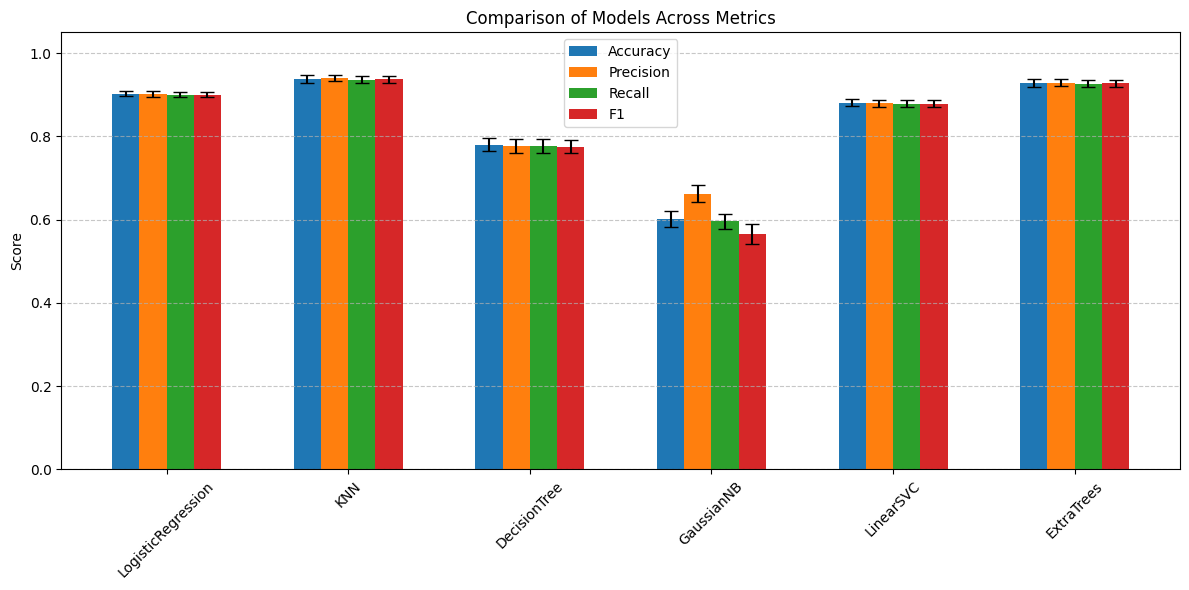

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# Metrics to plot
# -------------------------
metrics_mean = ['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean']
metrics_std  = ['accuracy_std', 'precision_std', 'recall_std', 'f1_std']
metric_labels = [m.replace("_mean","").replace("_"," ").title() for m in metrics_mean]

models_list = list(train_report.keys())
n_models = len(models_list)
n_metrics = len(metrics_mean)

# Bar width and positions
bar_width = 0.15
x = np.arange(n_models)

plt.figure(figsize=(n_models*2,6))  # make it wide if many models

# Plot each metric
for i, (mean_metric, std_metric) in enumerate(zip(metrics_mean, metrics_std)):
    means = [train_report[m][mean_metric] for m in models_list]
    stds  = [train_report[m][std_metric] for m in models_list]
    plt.bar(x + i*bar_width, means, width=bar_width, yerr=stds, capsize=5, label=metric_labels[i])

plt.xticks(x + bar_width*(n_metrics-1)/2, models_list, rotation=45)
plt.ylabel("Score")
plt.title("Comparison of Models Across Metrics")
plt.ylim(0,1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

From the plot above is clear that even classic ML methods perform very well for this dataset. This is because the problem is *easy*. In general, problems of image recognition are not so easy, because they need very heavy pre-processing. 

However, we are quite lucky in this case.

## CNN for classification

Next question is about how a Neural Network would perform. For this reason, we implemented a very simple example of a Convolutional Neural Network (CNN). A CNN is a a nerual network that is made mainly for image pre-processing, it applies concolutions and tries to detect useful local features from the input images. However, CNNs are quite strong models that can solve problems outside of the area of image processing as well.

The `SimpleCNN` consists of **two convolutional layers** followed by **max pooling**, and **two fully connected layers** at the end. Specifically, the first convolution uses 16 filters and the second uses 32 filters, each with a 3×3 kernel. After each convolution, a ReLU activation is applied, and max pooling reduces the spatial size of feature maps from 28×28 → 14×14 → 7×7. The feature maps are then flattened and passed through a fully connected layer with 128 neurons before the final output layer of 10 neurons, one per digit class.

Despite its simplicity, this architecture **already achieves near 100% accuracy** on MNIST. This is because MNIST digits are **low-resolution, grayscale, and highly standardized**, with limited variation in style or noise. Even a relatively shallow CNN can extract all the relevant features needed to distinguish digits perfectly. More complex architectures or generative models would be unnecessary here, as the task does not require handling high variability, color channels, or complex spatial patterns. The model’s excellent performance illustrates how **well-designed, simple CNNs are sufficient for straightforward image classification tasks** like MNIST.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [11]:
# -------------------------
# Prepare data for PyTorch
# -------------------------
# Convert to torch tensors
X_train_t = torch.tensor(train_images, dtype=torch.float32).unsqueeze(1)  # add channel dim
y_train_t = torch.tensor(train_labels, dtype=torch.long)

X_test_t = torch.tensor(test_images, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(test_labels, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [12]:
# -------------------------
# Define a simple CNN
# -------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 28->14
        x = self.pool(F.relu(self.conv2(x)))  # 14->7
        x = x.view(-1, 32 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [13]:
# -------------------------
# Initialize model, loss, optimizer
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score, balanced_accuracy_score
import numpy as np

# -------------------------
# Containers to store metrics
# -------------------------
history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_f1_macro": [],
    "train_precision_macro": [],
    "train_recall_macro": [],
    "train_balanced_acc": [],
    
    "val_accuracy": [],
    "val_f1_macro": [],
    "val_precision_macro": [],
    "val_recall_macro": [],
    "val_balanced_acc": []
}

# -------------------------
# Training loop
# -------------------------
epochs = 20  # demo

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    y_true_train, y_pred_train = [], []

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Track train predictions
        _, preds = torch.max(outputs, 1)
        y_true_train.extend(labels.cpu().numpy())
        y_pred_train.extend(preds.cpu().numpy())

        # Compute batch-level metrics for progress bar
        batch_acc = np.mean(np.array(y_true_train) == np.array(y_pred_train))
        batch_f1 = f1_score(y_true_train, y_pred_train, average="macro")
        loop.set_postfix({
            "Loss": f"{running_loss/len(train_loader.dataset):.4f}",
            "Train Acc": f"{batch_acc:.4f}",
            "Train F1": f"{batch_f1:.4f}"
        })

    # -------------------------
    # Store epoch metrics
    # -------------------------
    epoch_loss = running_loss / len(train_loader.dataset)
    train_acc = np.mean(np.array(y_true_train) == np.array(y_pred_train))
    train_f1 = f1_score(y_true_train, y_pred_train, average="macro")
    train_precision = precision_score(y_true_train, y_pred_train, average="macro")
    train_recall = recall_score(y_true_train, y_pred_train, average="macro")
    train_bal_acc = balanced_accuracy_score(y_true_train, y_pred_train)

    history["train_loss"].append(epoch_loss)
    history["train_accuracy"].append(train_acc)
    history["train_f1_macro"].append(train_f1)
    history["train_precision_macro"].append(train_precision)
    history["train_recall_macro"].append(train_recall)
    history["train_balanced_acc"].append(train_bal_acc)

    # -------------------------
    # Evaluate on validation set
    # -------------------------
    model.eval()
    y_true_val, y_pred_val = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true_val.extend(labels.cpu().numpy())
            y_pred_val.extend(preds.cpu().numpy())

    val_acc = np.mean(np.array(y_true_val) == np.array(y_pred_val))
    val_f1 = f1_score(y_true_val, y_pred_val, average="macro")
    val_precision = precision_score(y_true_val, y_pred_val, average="macro")
    val_recall = recall_score(y_true_val, y_pred_val, average="macro")
    val_bal_acc = balanced_accuracy_score(y_true_val, y_pred_val)

    history["val_accuracy"].append(val_acc)
    history["val_f1_macro"].append(val_f1)
    history["val_precision_macro"].append(val_precision)
    history["val_recall_macro"].append(val_recall)
    history["val_balanced_acc"].append(val_bal_acc)

    # -------------------------
    # Update progress bar for epoch summary
    # -------------------------
    loop.set_postfix({
        "Loss": f"{epoch_loss:.4f}",
        "Train Acc": f"{train_acc:.4f}",
        "Train F1": f"{train_f1:.4f}",
        "Val Acc": f"{val_acc:.4f}",
        "Val F1": f"{val_f1:.4f}"
    })

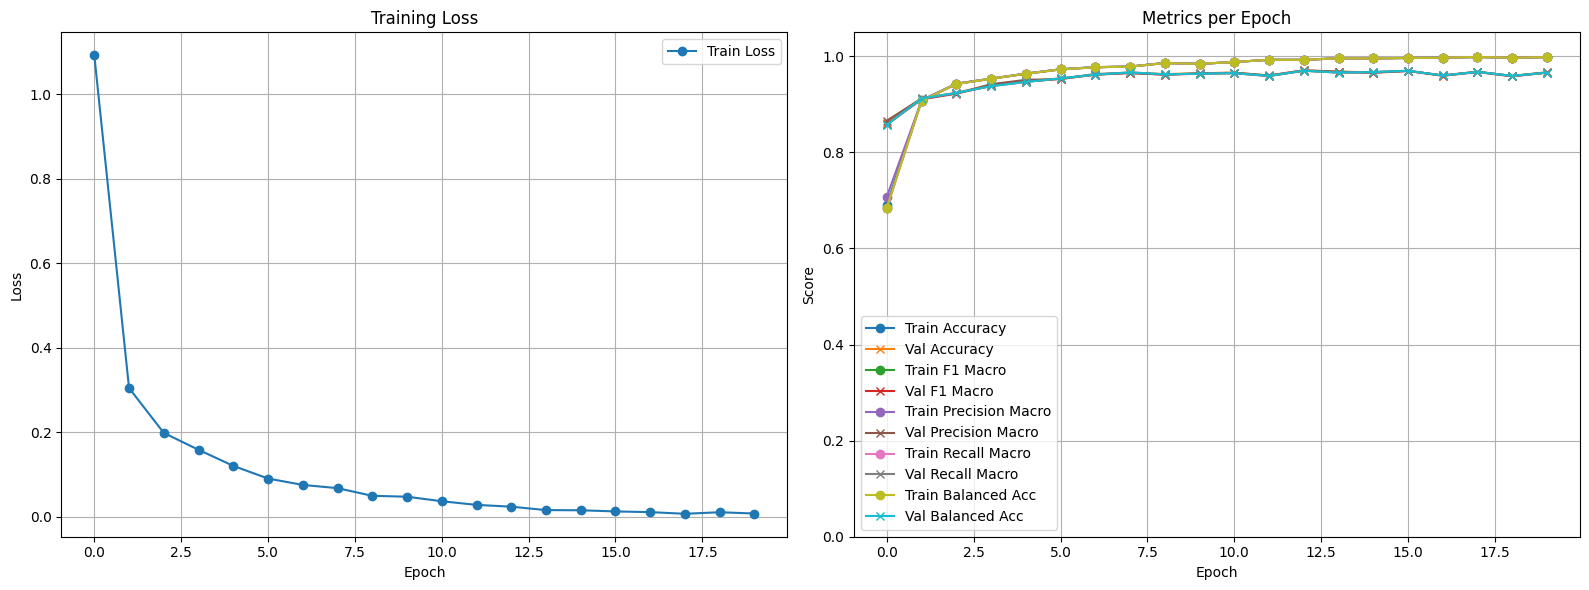

In [15]:
# -------------------------
# Plot train & val metrics
# -------------------------
plt.figure(figsize=(16,6))

# Loss
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss", marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Accuracy / metrics
plt.subplot(1,2,2)
metrics_to_plot = ["accuracy", "f1_macro", "precision_macro", "recall_macro", "balanced_acc"]
for m in metrics_to_plot:
    plt.plot(history[f"train_{m}"], marker='o', label=f"Train {m.replace('_',' ').title()}")
    plt.plot(history[f"val_{m}"], marker='x', label=f"Val {m.replace('_',' ').title()}")
plt.title("Metrics per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

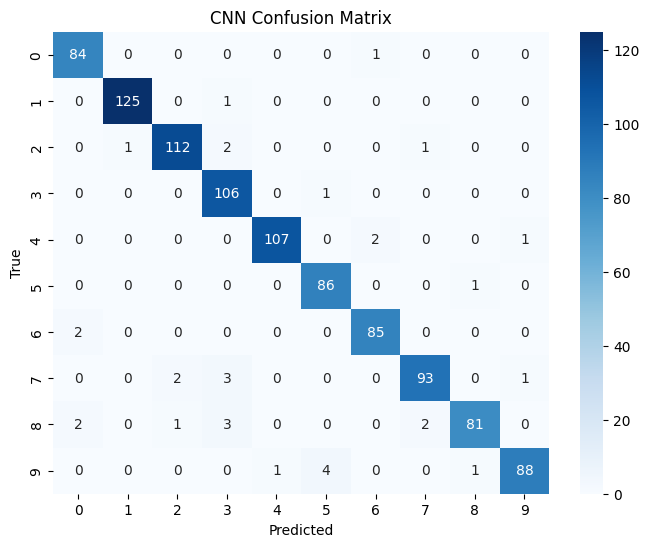

In [16]:
# -------------------------
# Optional: confusion matrix
# -------------------------
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
y_pred_list = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_pred_list.extend(preds.cpu().numpy())

cm = confusion_matrix(y_test, y_pred_list)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN Confusion Matrix")
plt.show()

# Generative Modeling

This section exists to solve a very interesting problem of digit generation. Here we do not want to have an algorithm that just recognizes digits (where we already showed that it is a very easy task). Instead of that, the algorithm takes as input a digit (or a sequence of digits) and outputs images similar to the MNIST dataset.

## Conditional Variational Autoencoder

The **Conditional Variational Autoencoder (CVAE)** is a generative model that can synthesize images conditioned on a class label. Unlike a standard VAE, which generates data purely from latent variables, the CVAE incorporates **side information**—in our case, the digit label (0–9)—so that the generated image corresponds to the desired digit.

**Model Structure:**

1. **Encoder:**

   * Takes an input image `x` and its one-hot encoded label `y`.
   * Extracts features using convolutional layers.
   * Outputs a latent representation as a **mean (`μ`)** and **log-variance (`log σ²`)**, parameterizing a Gaussian distribution in the latent space.

2. **Reparameterization Trick:**

   * Latent variable `z` is sampled as `z = μ + σ * ε` where `ε ~ N(0,1)`.
   * This allows gradients to backpropagate through the stochastic sampling.

3. **Decoder:**

   * Takes the latent vector `z` concatenated with the label `y`.
   * Reconstructs the image using transposed convolutions.
   * Outputs pixel probabilities between 0 and 1 (sigmoid activation).

**Loss Function:**

The CVAE optimizes a combination of two terms:


$$
\mathcal{L}_{CVAE} = - \mathbb{E}_{q(z|x,y)}[\log p(x|z,y)] + D_{KL}[q(z|x,y) \| p(z)]
$$


* **Reconstruction Loss (BCE):** Ensures the generated image is close to the original input.
* **KL Divergence:** Regularizes the latent space to follow a standard normal distribution, enabling smooth sampling.

**Capabilities:**

* **Conditional generation:** By providing a digit label, the model generates realistic handwritten digits corresponding to that class.
* **Stochasticity:** Sampling from the latent space produces diverse variations for the same digit.
* **Sequence generation (optional):** Feeding a sequence of labels allows generation of multi-digit patterns.

**Summary:**
The CVAE provides a simple yet powerful framework to generate labeled MNIST digits, balancing reconstruction accuracy with latent space regularization. It can be used for both **single-digit generation** and **conditional sequence generation**, making it a flexible tool for generative modeling experiments.

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# -------------------------
# One-hot encode labels
# -------------------------
num_classes = 10
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes=num_classes).float()

# -------------------------
# Prepare data
# -------------------------
X_train_t = torch.tensor(train_images, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(train_labels, dtype=torch.long)
y_train_oh = one_hot(y_train_t, num_classes)

X_test_t = torch.tensor(test_images, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(test_labels, dtype=torch.long)
y_test_oh = one_hot(y_test_t, num_classes)

train_dataset = TensorDataset(X_train_t, y_train_oh)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [18]:
# -------------------------
# CVAE Model
# -------------------------
latent_dim = 20

class CVAE(nn.Module):
    def __init__(self):
        super(CVAE, self).__init__()
        # Encoder
        self.enc_conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 28->14
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 14->7
            nn.ReLU()
        )
        self.fc1 = nn.Linear(64*7*7 + num_classes, 128)
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # Decoder
        self.fc2 = nn.Linear(latent_dim + num_classes, 128)
        self.fc3 = nn.Linear(128, 64*7*7)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(64,32,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,3,stride=2,padding=1,output_padding=1),
            nn.Sigmoid()
        )
    
    def encode(self, x, y):
        h = self.enc_conv(x)
        h = h.view(x.size(0), -1)
        h = torch.cat([h, y], dim=1)
        h = F.relu(self.fc1(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std
    
    def decode(self, z, y):
        h = torch.cat([z, y], dim=1)
        h = F.relu(self.fc2(h))
        h = F.relu(self.fc3(h))
        h = h.view(-1,64,7,7)
        x_recon = self.dec_conv(h)
        return x_recon
    
    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z, y)
        return x_recon, mu, logvar

# -------------------------
# Loss function
# -------------------------
def loss_fn(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [19]:
from tqdm import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# Containers for metrics
# -------------------------
history = {
    "total_loss": [],
    "recon_loss": [],
    "kl_loss": []
}

# -------------------------
# Training loop with single tqdm progress bar
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 400  # demo, can increase later

# Single tqdm for all epochs
loop = tqdm(range(epochs), desc="Training CVAE")

for epoch in loop:
    model.train()
    running_total, running_recon, running_kl = 0.0, 0.0, 0.0
    
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        x_recon, mu, logvar = model(x_batch, y_batch)
        
        # separate losses
        recon_loss = F.binary_cross_entropy(x_recon, x_batch, reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        total_loss = recon_loss + kl_loss
        
        total_loss.backward()
        optimizer.step()
        
        # accumulate metrics
        running_total += total_loss.item()
        running_recon += recon_loss.item()
        running_kl += kl_loss.item()
    
    # average per sample
    n_samples = len(train_loader.dataset)
    avg_total = running_total / n_samples
    avg_recon = running_recon / n_samples
    avg_kl = running_kl / n_samples
    
    # store history
    history["total_loss"].append(avg_total)
    history["recon_loss"].append(avg_recon)
    history["kl_loss"].append(avg_kl)
    
    # update progress bar postfix only
    loop.set_postfix({
        "Total": f"{avg_total:.4f}",
        "Recon": f"{avg_recon:.4f}",
        "KL": f"{avg_kl:.4f}"
    })

Training CVAE: 100%|██████████| 400/400 [01:12<00:00,  5.53it/s, Total=83.7418, Recon=64.8883, KL=18.8535]


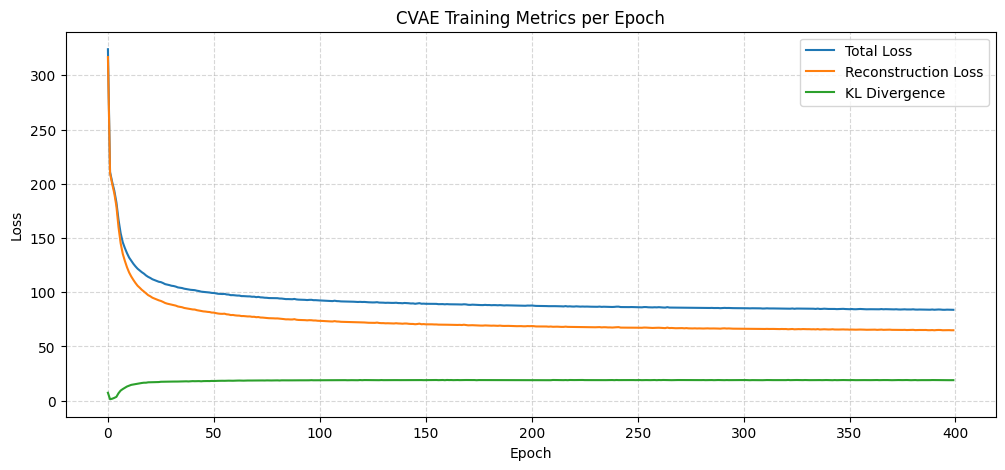

In [20]:
import matplotlib.pyplot as plt

# -------------------------
# Plot training metrics (lines only)
# -------------------------
plt.figure(figsize=(12,5))

plt.plot(history["total_loss"], label="Total Loss")
plt.plot(history["recon_loss"], label="Reconstruction Loss")
plt.plot(history["kl_loss"], label="KL Divergence")

plt.title("CVAE Training Metrics per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

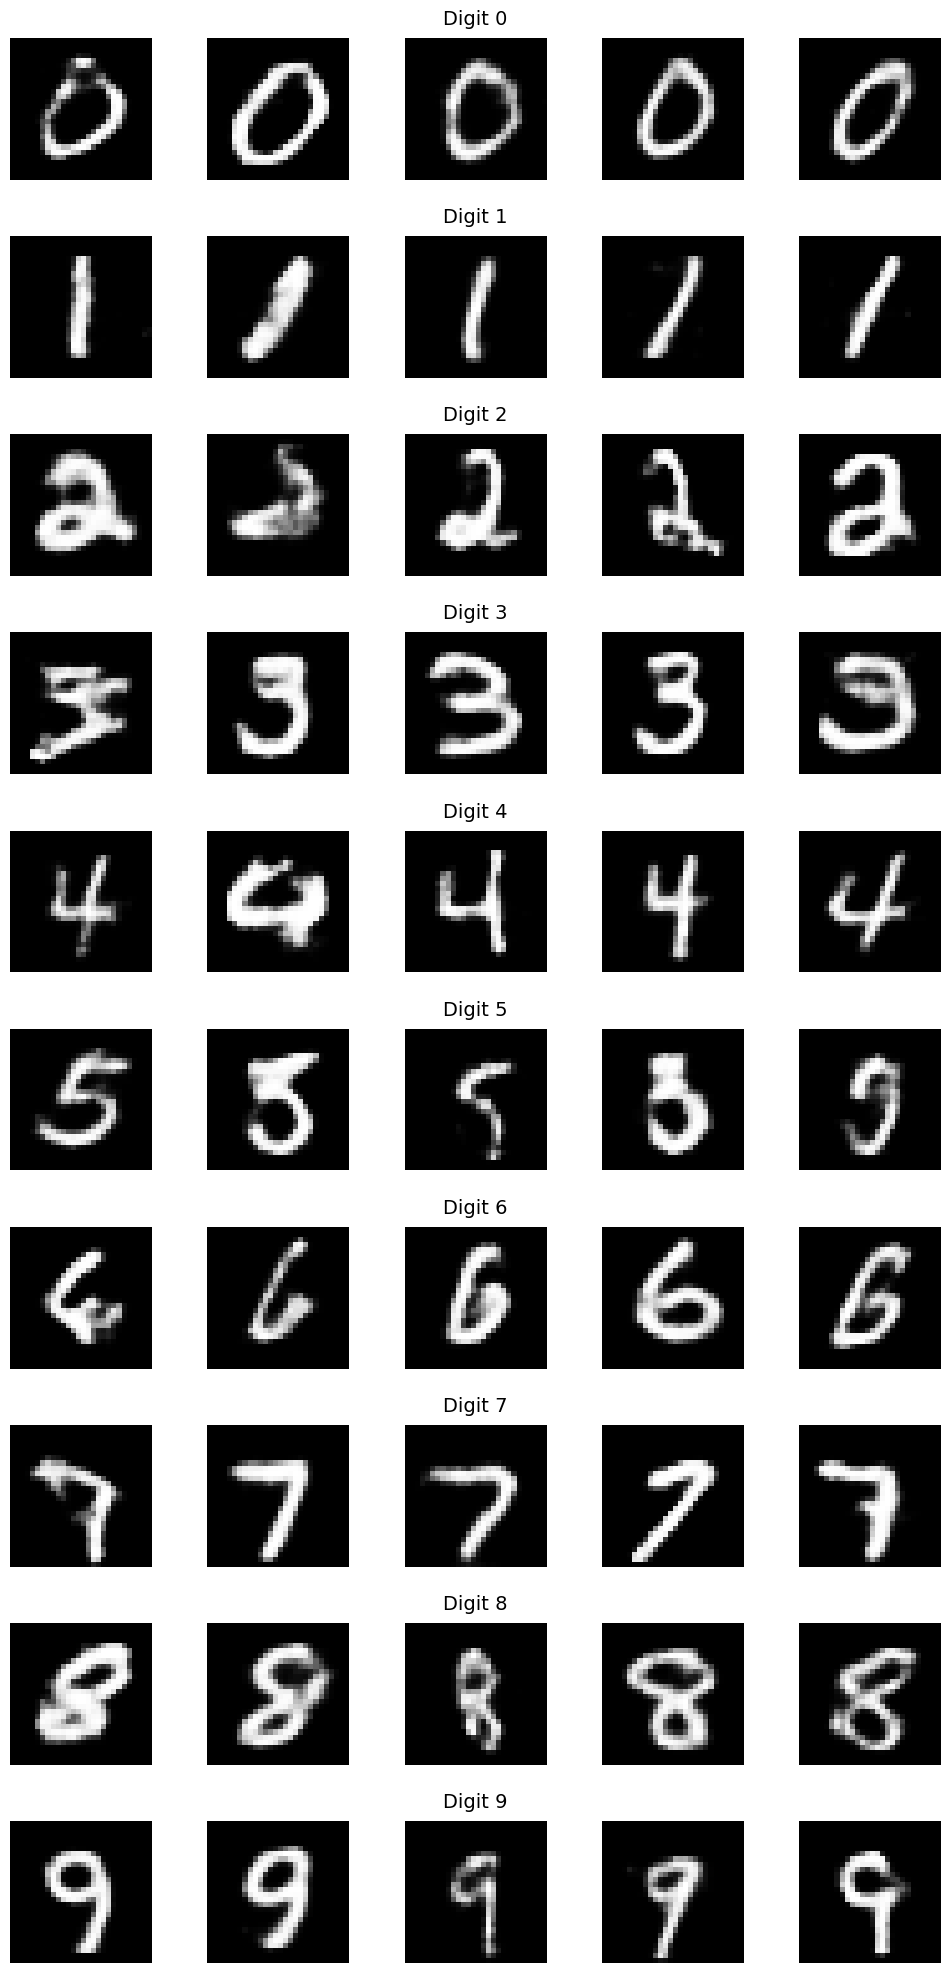

In [21]:
import matplotlib.pyplot as plt
import torch

def generate_images_all_digits(model, n_samples=5, latent_dim=20, num_classes=10):
    model.eval()
    
    # Prepare labels 0-9
    labels = torch.arange(num_classes).repeat_interleave(n_samples)
    y = one_hot(labels, num_classes).to(device)
    
    # Sample latent vectors
    z = torch.randn(num_classes * n_samples, latent_dim).to(device)
    
    # Generate images
    with torch.no_grad():
        imgs = model.decode(z, y).cpu().numpy()
    imgs = imgs.squeeze(1)  # remove channel dim
    
    # -------------------------
    # Plot all images in a grid
    # -------------------------
    fig, axes = plt.subplots(num_classes, n_samples, figsize=(n_samples*2.5, num_classes*2.5))
    
    for i in range(num_classes):
        for j in range(n_samples):
            ax = axes[i, j]
            ax.imshow(imgs[i*n_samples + j], cmap='gray')
            ax.axis('off')
            # Add title above middle column
            if j == n_samples // 2:
                ax.set_title(f"Digit {i}", fontsize=14, pad=10)
    
    plt.subplots_adjust(wspace=0.1, hspace=0.4)
    plt.show()

# Example: generate 5 samples per digit
generate_images_all_digits(model, n_samples=5, latent_dim=latent_dim, num_classes=10)

In [22]:
def generate_digit_sequence(model, digit_sequence, n_samples_per_digit=1, latent_dim=20):
    """
    Generate images for a sequence of digits using the CVAE.
    
    Args:
        model: trained CVAE model
        digit_sequence: list of integers (e.g., [1, 2, 3])
        n_samples_per_digit: number of variations per digit
        latent_dim: dimension of latent space
    """
    model.eval()
    
    sequence_len = len(digit_sequence)
    total_samples = sequence_len * n_samples_per_digit
    
    # Prepare labels
    labels = torch.tensor(digit_sequence).repeat_interleave(n_samples_per_digit)
    y = one_hot(labels, num_classes).to(device)
    
    # Sample latent vectors
    z = torch.randn(total_samples, latent_dim).to(device)
    
    # Generate images
    with torch.no_grad():
        imgs = model.decode(z, y).cpu().numpy()
    imgs = imgs.squeeze(1)  # remove channel dimension
    
    # -------------------------
    # Plot the sequence
    # -------------------------
    plt.figure(figsize=(total_samples*2, 2))
    
    for i in range(total_samples):
        plt.subplot(1, total_samples, i+1)
        plt.imshow(imgs[i], cmap='gray')
        plt.axis('off')
        # Label only the first sample for each digit
        if i % n_samples_per_digit == n_samples_per_digit // 2:
            plt.title(f"Digit {labels[i].item()}", fontsize=12, pad=5)
    
    plt.show()

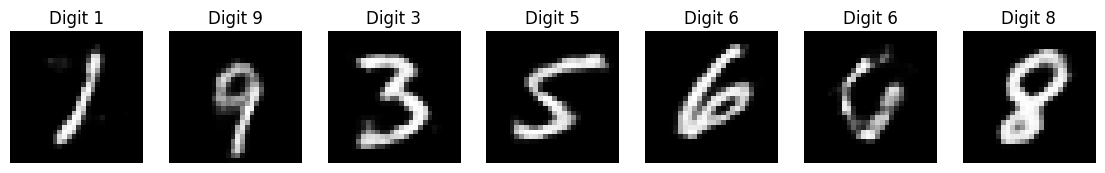

In [23]:
generate_digit_sequence(model, [1, 9, 3, 5, 6, 6, 8], n_samples_per_digit=1, latent_dim=latent_dim)

## Denoising/Reconstruction Task


The purpose of this task is to **train a model that can reconstruct or denoise images of handwritten digits** from the MNIST dataset. In practice, we want to take an input image — which could be **corrupted by noise, incomplete, or partially missing** — and have the model generate a **plausible, clean version of the original digit**.

This is useful in several contexts:

* **Image denoising**: cleaning scanned or noisy handwritten data.
* **Pattern completion**: filling in missing or occluded parts of an image.
* **Feature extraction / pretraining**: RBMs can learn high-level representations of data that can be useful for other tasks, like classification.


### What is a Restricted Boltzmann Machine (RBM)?

A **Restricted Boltzmann Machine** is a type of **probabilistic, generative neural network** that models the **distribution of input data**. Key properties:

1. **Two layers**:

   * **Visible layer**: represents the observed data (e.g., pixels of MNIST images).
   * **Hidden layer**: learns latent features (e.g., strokes or curves that define digits).

2. **Symmetric connections** between visible and hidden units, but **no connections within a layer** (hence “restricted”).

3. **Stochastic sampling**:

   * Each hidden unit is activated probabilistically depending on visible units.
   * Visible units are reconstructed from hidden activations.

### How RBMs Solve This Task

* The RBM **learns correlations between pixels** across the entire dataset. For MNIST, this means it captures **typical shapes and strokes for digits**.
* During **reconstruction**, the model takes an input image and:

  1. Computes hidden activations (which features are “on”).
  2. Generates a visible reconstruction from those activations.
* As a result, **noisy or partially missing digits are projected onto the learned data distribution**, producing a clean, plausible version.

**In other words:** the RBM acts like a **pattern completion and denoising machine** — it doesn’t “know” labels by default but learns the **underlying structure of handwritten digits** and uses that knowledge to reconstruct them.


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [25]:
# -------------------------
# Prepare MNIST
# -------------------------
transform = transforms.Compose([
    transforms.ToTensor(),  # 0-1
    # Binarize for RBM
    transforms.Lambda(lambda x: (x > 0.5).float())
])

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RBM(nn.Module):
    def __init__(self, n_vis=784, n_hid=256, n_classes=None):
        """
        n_vis: number of visible units (pixels)
        n_hid: number of hidden units
        n_classes: if given, conditional RBM with label embedding
        """
        super(RBM, self).__init__()
        self.n_vis = n_vis
        self.n_hid = n_hid
        self.n_classes = n_classes
        
        # RBM parameters
        self.W = nn.Parameter(torch.randn(n_hid, n_vis) * 0.01)
        self.h_bias = nn.Parameter(torch.zeros(n_hid))
        self.v_bias = nn.Parameter(torch.zeros(n_vis))
        
        # Conditional RBM
        if n_classes is not None:
            self.label_emb = nn.Linear(n_classes, n_hid, bias=False)  # add label contribution to hidden
        else:
            self.label_emb = None

    def sample_h(self, v, y=None, temperature=1.0):
        """Sample hidden given visible (and optional label)"""
        pre_activation = F.linear(v, self.W, self.h_bias)
        if self.label_emb is not None and y is not None:
            pre_activation += self.label_emb(y)
        p_h = torch.sigmoid(pre_activation / temperature)
        return p_h, torch.bernoulli(p_h)

    def sample_v(self, h, temperature=1.0):
        """Sample visible given hidden"""
        p_v = torch.sigmoid(F.linear(h, self.W.t(), self.v_bias) / temperature)
        return p_v, torch.bernoulli(p_v)

    def gibbs_sampling(self, v0, y=None, k=1, temperature=1.0):
        """Run k steps of Gibbs sampling starting from v0"""
        v = v0
        for _ in range(k):
            p_h, h = self.sample_h(v, y=y, temperature=temperature)
            p_v, v = self.sample_v(h, temperature=temperature)
        return v, p_h

    def forward(self, v, y=None, k=1, temperature=1.0):
        """
        Perform forward pass with k Gibbs steps
        Returns:
            v_k: reconstructed visible samples
            h_prob: hidden probabilities after last step
        """
        v_k, h_prob = self.gibbs_sampling(v, y=y, k=k, temperature=temperature)
        return v_k, h_prob

    # -------------------------
    # Helper methods for generation
    # -------------------------
    @torch.no_grad()
    def reconstruct(self, v, y=None, steps=5, temperature=1.0):
        """Reconstruct images from v (or conditioned on y if cRBM)"""
        v_recon, _ = self.gibbs_sampling(v, y=y, k=steps, temperature=temperature)
        return v_recon

    @torch.no_grad()
    def sample(self, n_samples=10, y=None, steps=10, temperature=1.0):
        """Generate new visible samples"""
        v = torch.bernoulli(torch.rand(n_samples, self.n_vis, device=self.W.device))
        v_sample, _ = self.gibbs_sampling(v, y=y, k=steps, temperature=temperature)
        return v_sample

In [27]:
# -------------------------
# Training parameters
# -------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
rbm = RBM(n_vis=784, n_hid=256).to(device)
optimizer = torch.optim.SGD(rbm.parameters(), lr=0.1)
epochs = 200
k = 1  # CD-k

# -------------------------
# Metrics storage
# -------------------------
history = {
    "recon_loss": [],
    "mse": [],
    "pixel_acc": []
}

In [28]:
# -------------------------
# Training loop with progress bar
# -------------------------
from tqdm import tqdm

for epoch in range(epochs):
    running_loss = 0.0
    running_mse = 0.0
    running_acc = 0.0
    n_batches = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for x_batch, _ in loop:
        x_batch = x_batch.view(-1, 784).to(device)
        
        # -------------------------
        # Contrastive Divergence using new RBM methods
        # -------------------------
        v0 = x_batch
        vk, _ = rbm.gibbs_sampling(v0, k=k)  # k-step Gibbs sampling
        p_h0, h0 = rbm.sample_h(v0)
        p_hk, hk = rbm.sample_h(vk)

        # -------------------------
        # Compute gradients manually
        # -------------------------
        positive_grad = torch.matmul(h0.t(), v0)
        negative_grad = torch.matmul(hk.t(), vk)

        optimizer.zero_grad()
        rbm.W.grad = -(positive_grad - negative_grad) / v0.size(0)
        rbm.v_bias.grad = -torch.mean(v0 - vk, dim=0)
        rbm.h_bias.grad = -torch.mean(h0 - hk, dim=0)
        optimizer.step()

        # -------------------------
        # Compute metrics
        # -------------------------
        mse = torch.mean((v0 - vk)**2).item()
        pixel_acc = torch.mean((vk.round() == v0).float()).item()

        running_loss += mse
        running_mse += mse
        running_acc += pixel_acc
        n_batches += 1

        # -------------------------
        # Update tqdm postfix only
        # -------------------------
        loop.set_postfix({
            "Recon Loss": running_loss / n_batches,
            "MSE": running_mse / n_batches,
            "Pixel Acc": running_acc / n_batches
        })

    # -------------------------
    # Store epoch metrics
    # -------------------------
    history["recon_loss"].append(running_loss / n_batches)
    history["mse"].append(running_mse / n_batches)
    history["pixel_acc"].append(running_acc / n_batches)

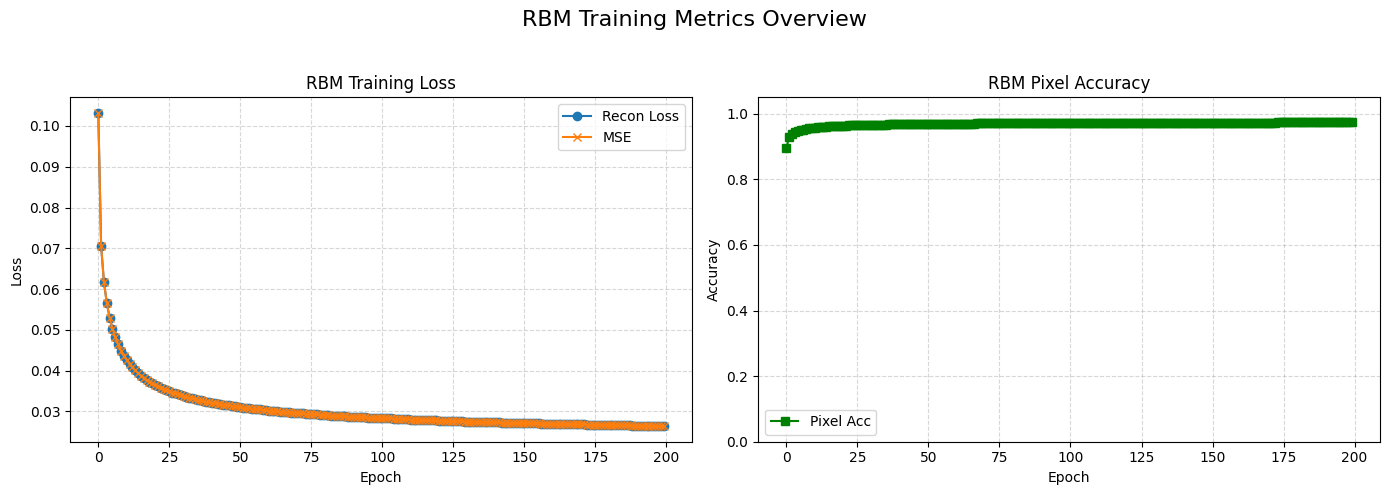

In [29]:
import matplotlib.pyplot as plt

# -------------------------
# Separate plots for clarity
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Plot losses
axes[0].plot(history["recon_loss"], label="Recon Loss", marker='o')
axes[0].plot(history["mse"], label="MSE", marker='x')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("RBM Training Loss")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot accuracy
axes[1].plot(history["pixel_acc"], label="Pixel Acc", color='green', marker='s')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("RBM Pixel Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("RBM Training Metrics Overview", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

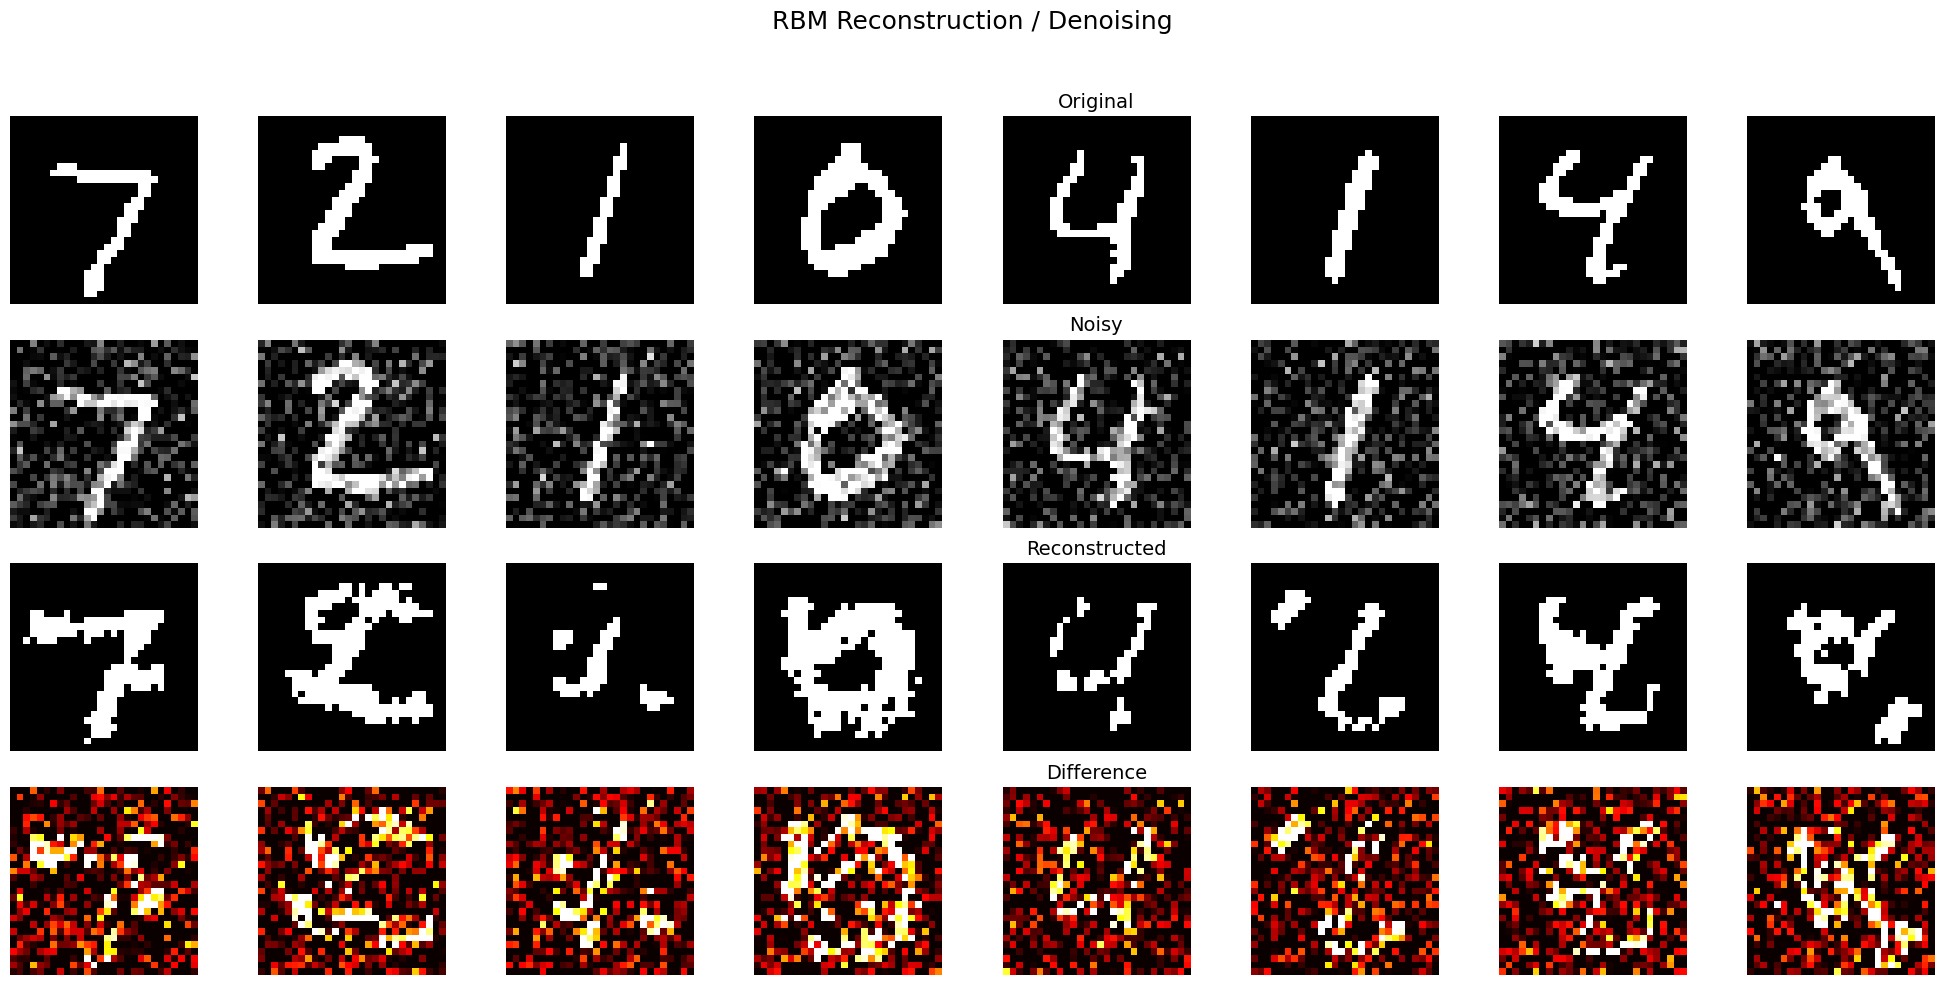

In [30]:
import matplotlib.pyplot as plt

# -------------------------
# Pick some test images
# -------------------------
n_show = 8
test_imgs, _ = next(iter(test_loader))
noisy_imgs = test_imgs + 0.3*torch.randn_like(test_imgs)
noisy_imgs = torch.clamp(noisy_imgs, 0, 1)

# Move to same device as RBM
noisy_imgs = noisy_imgs.to(next(rbm.parameters()).device)

# Reconstruct with RBM
reconstructed = rbm.reconstruct(noisy_imgs.view(-1, 784), steps=10)
reconstructed = reconstructed.view(-1, 1, 28, 28)  # reshape back to images

# -------------------------
# Plot nicely
# -------------------------
fig, axes = plt.subplots(4, n_show, figsize=(n_show*2.5, 10))
fig.suptitle("RBM Reconstruction / Denoising", fontsize=18)

for i in range(n_show):
    # Original
    axes[0,i].imshow(test_imgs[i,0], cmap='gray')
    axes[0,i].axis('off')
    if i == n_show//2:
        axes[0,i].set_title("Original", fontsize=14)

    # Noisy
    axes[1,i].imshow(noisy_imgs[i,0].cpu(), cmap='gray')
    axes[1,i].axis('off')
    if i == n_show//2:
        axes[1,i].set_title("Noisy", fontsize=14)

    # Reconstructed
    axes[2,i].imshow(reconstructed[i,0].cpu(), cmap='gray')
    axes[2,i].axis('off')
    if i == n_show//2:
        axes[2,i].set_title("Reconstructed", fontsize=14)
    
    # Difference (abs)
    diff = torch.abs(reconstructed[i,0] - noisy_imgs[i,0])
    axes[3,i].imshow(diff.cpu(), cmap='hot')
    axes[3,i].axis('off')
    if i == n_show//2:
        axes[3,i].set_title("Difference", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()